In [1]:
import math
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

def f(x):
    return 3*x**2 - 4*x + 5


In [3]:
f(3.0)

20.0

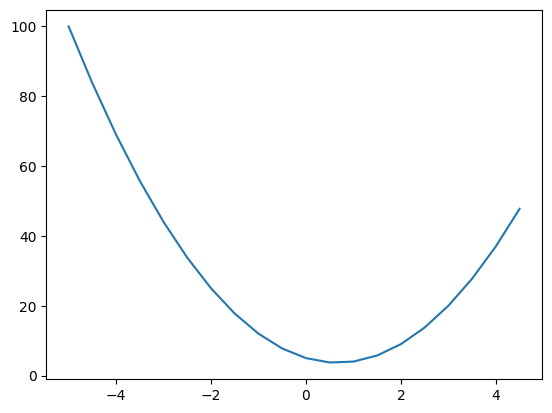

In [2]:
xs = np.arange(-5, 5, 0.5)
ys = f(xs)
plt.plot(xs, ys)

In [3]:
h = 0.000000001 # nuge
x = 2/3
(f(x + h) - f(x))/h

0.0

In [4]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [19]:
h = 0.0001
# inputs
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c  # bump a by h
c +=h
d2 = a*b + c

print("d1",d1) # 
print("d2",d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [5]:
class Value:

    def __init__(self, data, _children=(), _op ='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

a = Value(2.0,label='a')
b = Value(-3.0,label='b')
#a + b
#c = a.__add__(b)
c = Value(10.0,label='c')
#a*b + c
#d = (a.__mul__(b)).__add__(c)
d = a*b + c;d.label='d'


In [6]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [7]:
d._op

'+'

In [8]:
d.label

'd'

In [10]:
from graphviz import Digraph

def trace(root):
    nodes, edges  = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edgs.add(child, v)
                build(child)
    bulid(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ data %.4f}" % (n.data), shape='record')
        if n._op:
            node.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edgs:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot
    

ModuleNotFoundError: No module named 'graphviz'